# Q01

Setup and Data Loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="deep")

data = np.genfromtxt('/content/lines.csv', delimiter=',', skip_header=1)

X_cols = data[:, :3]
Y_cols = data[:, 3:]

x_all = X_cols.flatten()
y_all = Y_cols.flatten()

print(f"Dataset successfully loaded. Shape: {data.shape}")

Dataset successfully loaded. Shape: (100, 6)


Part 1(a) - Total Least Squares (TLS)

Q1(a) TLS Parameters for Line 1
a: -0.773562, b: 0.633721, d: -3.794192
Equation: -0.7736x + 0.6337y = -3.7942


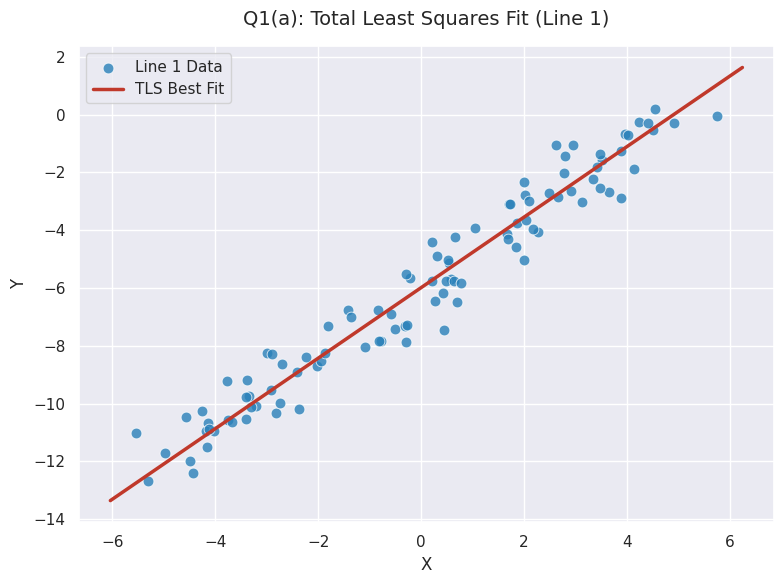

In [3]:
def compute_tls(x, y):
    mean_x, mean_y = np.mean(x), np.mean(y)

    U = np.vstack((x - mean_x, y - mean_y)).T

    covariance_matrix = U.T @ U
    eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

    min_eigen_idx = np.argmin(eigenvalues)
    a, b = eigenvectors[:, min_eigen_idx]

    d = a * mean_x + b * mean_y

    return a, b, d

x1 = X_cols[:, 0]
y1 = Y_cols[:, 0]

a1, b1, d1 = compute_tls(x1, y1)

print("Q1(a) TLS Parameters for Line 1")
print(f"a: {a1:.6f}, b: {b1:.6f}, d: {d1:.6f}")
print(f"Equation: {a1:.4f}x + {b1:.4f}y = {d1:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=x1, y=y1, color='#2980b9', s=60, label='Line 1 Data', alpha=0.8)

x_line = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 100)
y_line = (d1 - a1 * x_line) / b1

sns.lineplot(x=x_line, y=y_line, color='#c0392b', linewidth=2.5, label='TLS Best Fit')

plt.title("Q1(a): Total Least Squares Fit (Line 1)", fontsize=14, pad=15)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.tight_layout()
plt.savefig('q1a_unique_fit.png', dpi=300)
plt.show()

Part 1(b) - Custom RANSAC Algorithm


In [5]:
def calculate_perpendicular_distance(x, y, a, b, d):
    return np.abs(a * x + b * y - d) / np.sqrt(a**2 + b**2)

def custom_ransac(x, y, iterations=2000, threshold=0.5, min_consensus=10):

    best_inlier_indices = []
    n_points = len(x)

    for _ in range(iterations):
        sample_idx = np.random.choice(n_points, 2, replace=False)
        xs, ys = x[sample_idx], y[sample_idx]

        dx = xs[1] - xs[0]
        dy = ys[1] - ys[0]

        if dx == 0 and dy == 0:
            continue

        a, b = dy, -dx
        d = a * xs[0] + b * ys[0]

        norm = np.sqrt(a**2 + b**2)
        a, b, d = a/norm, b/norm, d/norm

        distances = calculate_perpendicular_distance(x, y, a, b, d)
        inliers = np.where(distances < threshold)[0]

        if len(inliers) > len(best_inlier_indices):
            best_inlier_indices = inliers

    if len(best_inlier_indices) >= min_consensus:
        a_ref, b_ref, d_ref = compute_tls(x[best_inlier_indices], y[best_inlier_indices])

        final_dists = calculate_perpendicular_distance(x, y, a_ref, b_ref, d_ref)
        final_inliers = np.where(final_dists < threshold)[0]
        return (a_ref, b_ref, d_ref), final_inliers

    return None, []

Extract Three Lines and Plot

Q1(b) RANSAC Line Extraction
Line 1: 77 inliers found.
   Params: a=0.44049, b=0.89776, d=1.80315 (y = -0.491x + 2.009)
Line 2: 62 inliers found.
   Params: a=-0.71777, b=0.69628, d=0.76220 (y = 1.031x + 1.095)
Line 3: 60 inliers found.
   Params: a=-0.76220, b=0.64734, d=-4.08144 (y = 1.177x + -6.305)

Remaining unclassified (outlier) points: 101


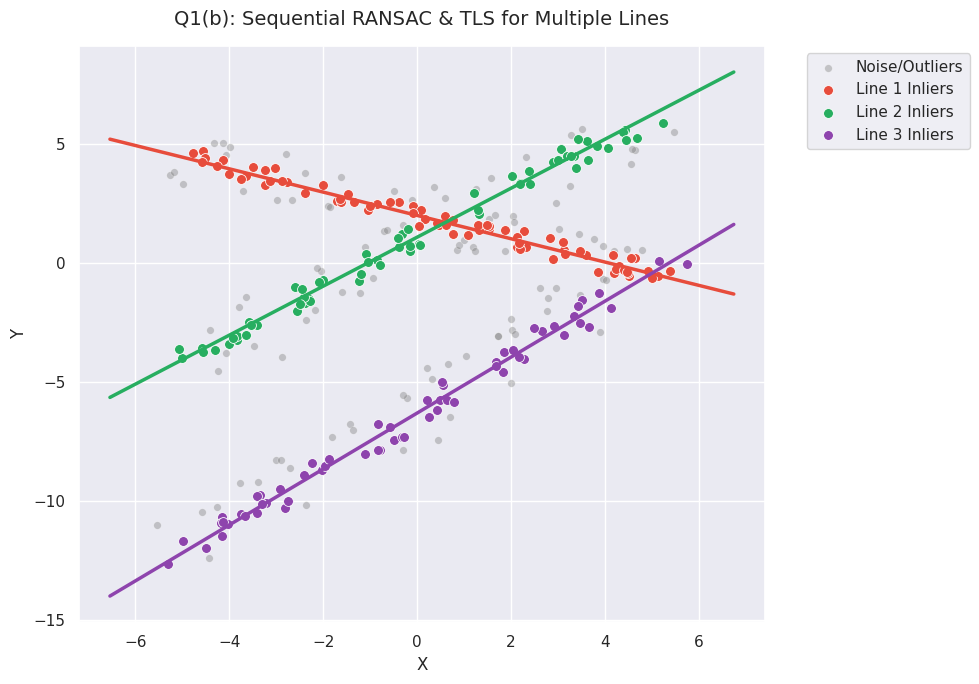

In [7]:
np.random.seed(42)

rem_x = x_all.copy()
rem_y = y_all.copy()

fitted_lines = []
inlier_x_groups = []
inlier_y_groups = []
colors = ['#e74c3c', '#27ae60', '#8e44ad']

print("Q1(b) RANSAC Line Extraction")
for i in range(3):
    params, inlier_idx = custom_ransac(rem_x, rem_y, iterations=2000, threshold=0.45)

    if params is None:
        print(f"Failed to find line {i+1}")
        break

    a, b, d = params
    m, c = -a/b, d/b

    print(f"Line {i+1}: {len(inlier_idx)} inliers found.")
    print(f"   Params: a={a:.5f}, b={b:.5f}, d={d:.5f} (y = {m:.3f}x + {c:.3f})")

    fitted_lines.append(params)
    inlier_x_groups.append(rem_x[inlier_idx])
    inlier_y_groups.append(rem_y[inlier_idx])

    mask = np.ones(len(rem_x), dtype=bool)
    mask[inlier_idx] = False
    rem_x = rem_x[mask]
    rem_y = rem_y[mask]

print(f"\nRemaining unclassified (outlier) points: {len(rem_x)}")

plt.figure(figsize=(10, 7))

sns.scatterplot(x=rem_x, y=rem_y, color='grey', s=30, alpha=0.4, label='Noise/Outliers')

x_plot = np.linspace(x_all.min() - 1, x_all.max() + 1, 100)

for i in range(3):
    sns.scatterplot(x=inlier_x_groups[i], y=inlier_y_groups[i],
                    color=colors[i], s=50, label=f'Line {i+1} Inliers', zorder=3)

    a, b, d = fitted_lines[i]
    y_plot = (d - a * x_plot) / b
    sns.lineplot(x=x_plot, y=y_plot, color=colors[i], linewidth=2.5, zorder=4)

plt.title("Q1(b): Sequential RANSAC & TLS for Multiple Lines", fontsize=14, pad=15)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('q1b_unique_ransac.png', dpi=300)
plt.show()